<a href="https://colab.research.google.com/github/MelwinKalayil/Cortex/blob/main/Fire_SmokeDataTraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install -q ultralytics roboflow

In [9]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="wDZ8p6ZFYkYbffXAnwGc")
project = rf.workspace("cpe313-advanced-ml-and-deep-learning").project("fire-and-smoke-mbhix")
version = project.version(6)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [10]:
from ultralytics import YOLO

fire_model = YOLO("yolov8n.pt")
fire_results = fire_model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=35,
    imgsz=640,
    batch=16,
    device=0,
    workers=4,
    name="fire_smoke_yolov8n"
)
best_fire_model = YOLO("runs/detect/fire_smoke_yolov8n/weights/best.pt")
best_fire_model.export(format="onnx", imgsz=640)

# 5. Download weights to local machine
from google.colab import files
files.download("runs/detect/fire_smoke_yolov8n/weights/best.onnx")
import shutil
from google.colab import files

# 1. Zip the entire 'runs' directory
print("Compressing runs folder...")
shutil.make_archive('all_training_runs', 'zip', '/content/runs')

# 2. Trigger browser download
print("Starting download...")
files.download('all_training_runs.zip')

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Fire-and-Smoke-6/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fire_smoke_yolov8n-3, nbs=64, nms=None, 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Compressing runs folder...
Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2007.9±654.0 MB/s, size: 45.4 KB)
val: Scanning /content/Fire-and-Smoke-6/valid/labels.cache... 757 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 757/757 176.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 48/48 4.9it/s 9.8s
                   all        757       1788      0.588      0.465      0.483      0.249
                  Fire        584       1129      0.538      0.363      0.387      0.183
                 Smoke        552        659      0.638      0.568       0.58      0.316
Speed: 1.6ms preprocess, 3.8ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val-2


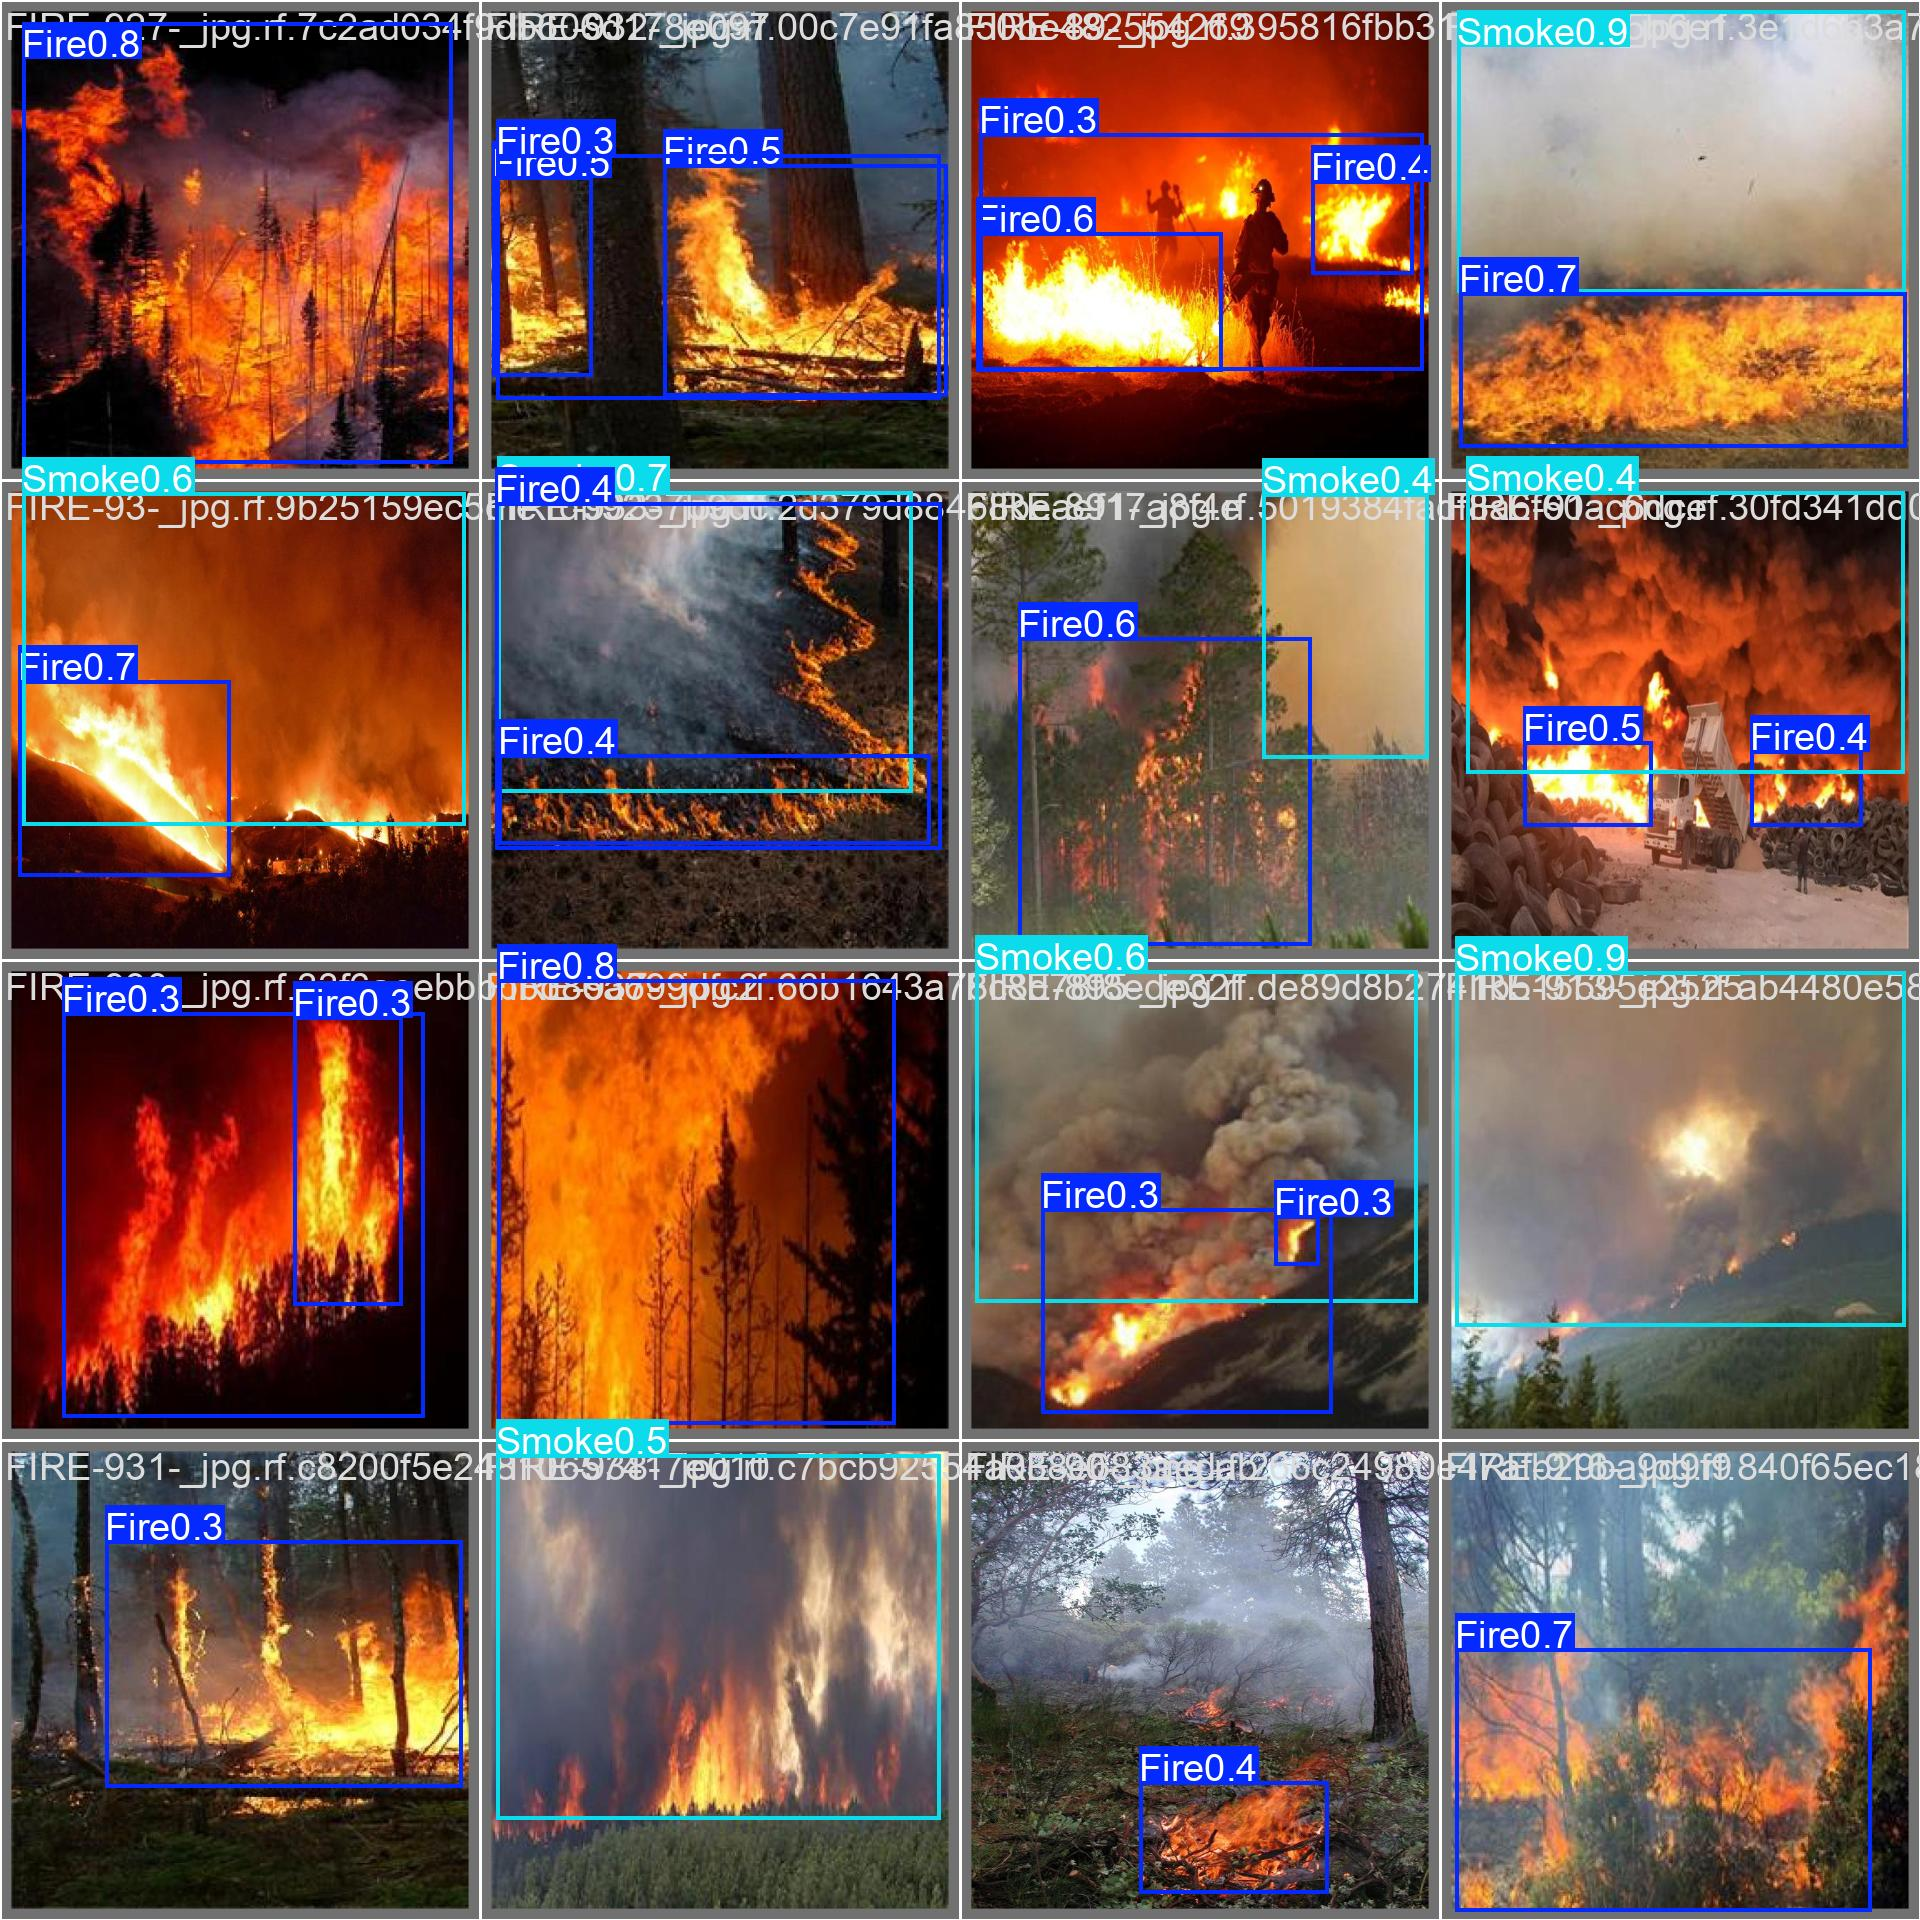

In [13]:
# Evaluate performance metrics (mAP50, mAP50-95)
metrics = fire_model.val()

# Display a sample batch of predictions
from IPython.display import Image
Image(filename="runs/detect/fire_smoke_yolov8n-3/val_batch0_pred.jpg")

--- Training Metrics (Loss & mAP Curves) ---


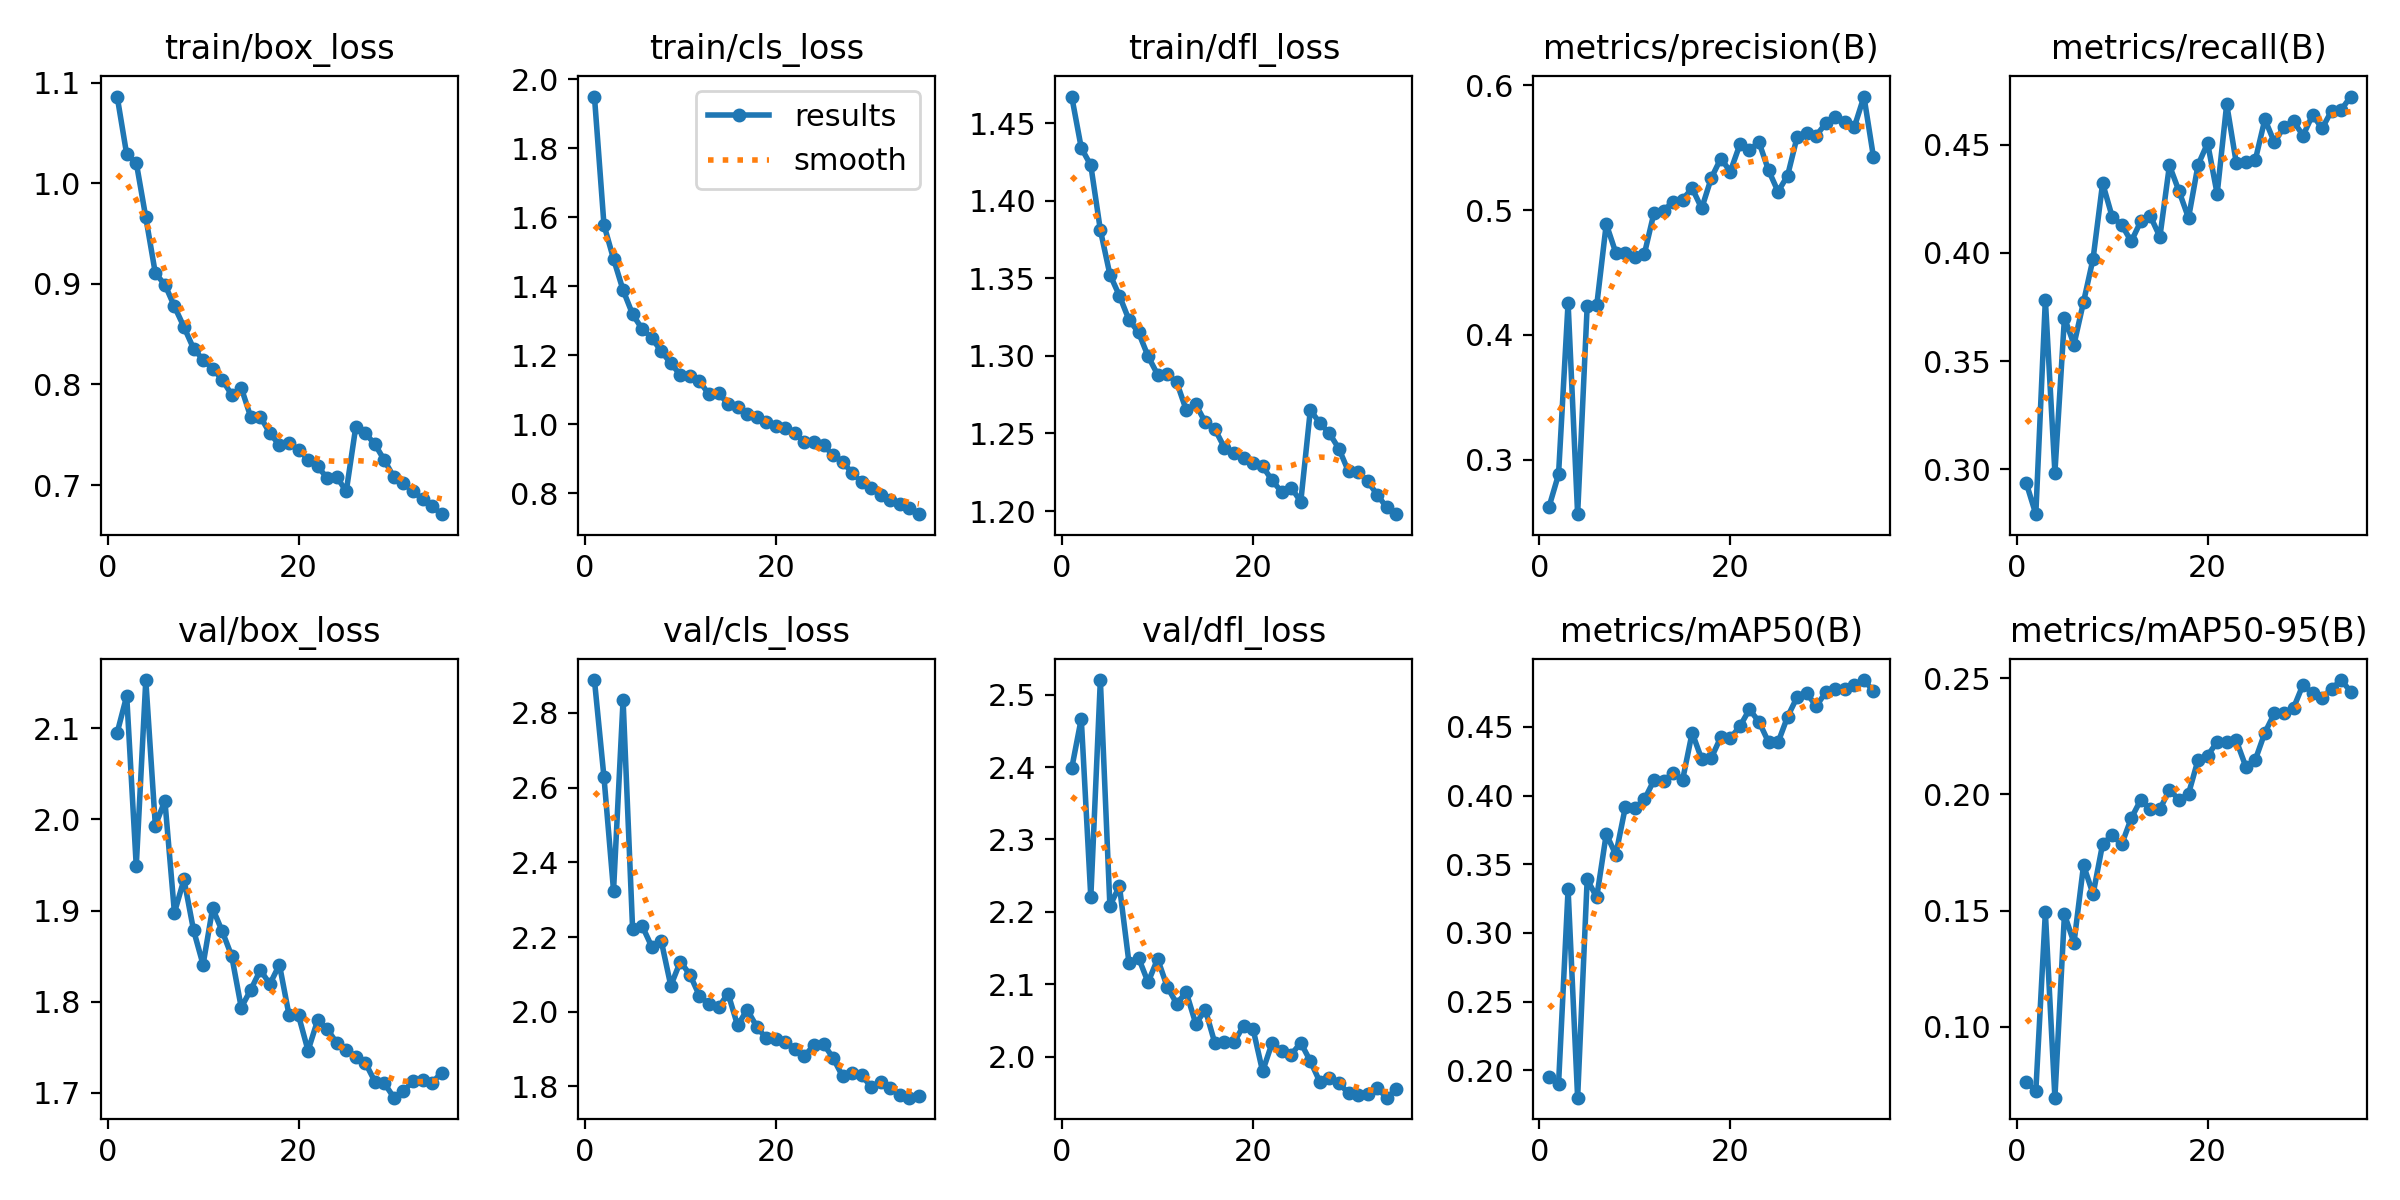

--- Confusion Matrix ---


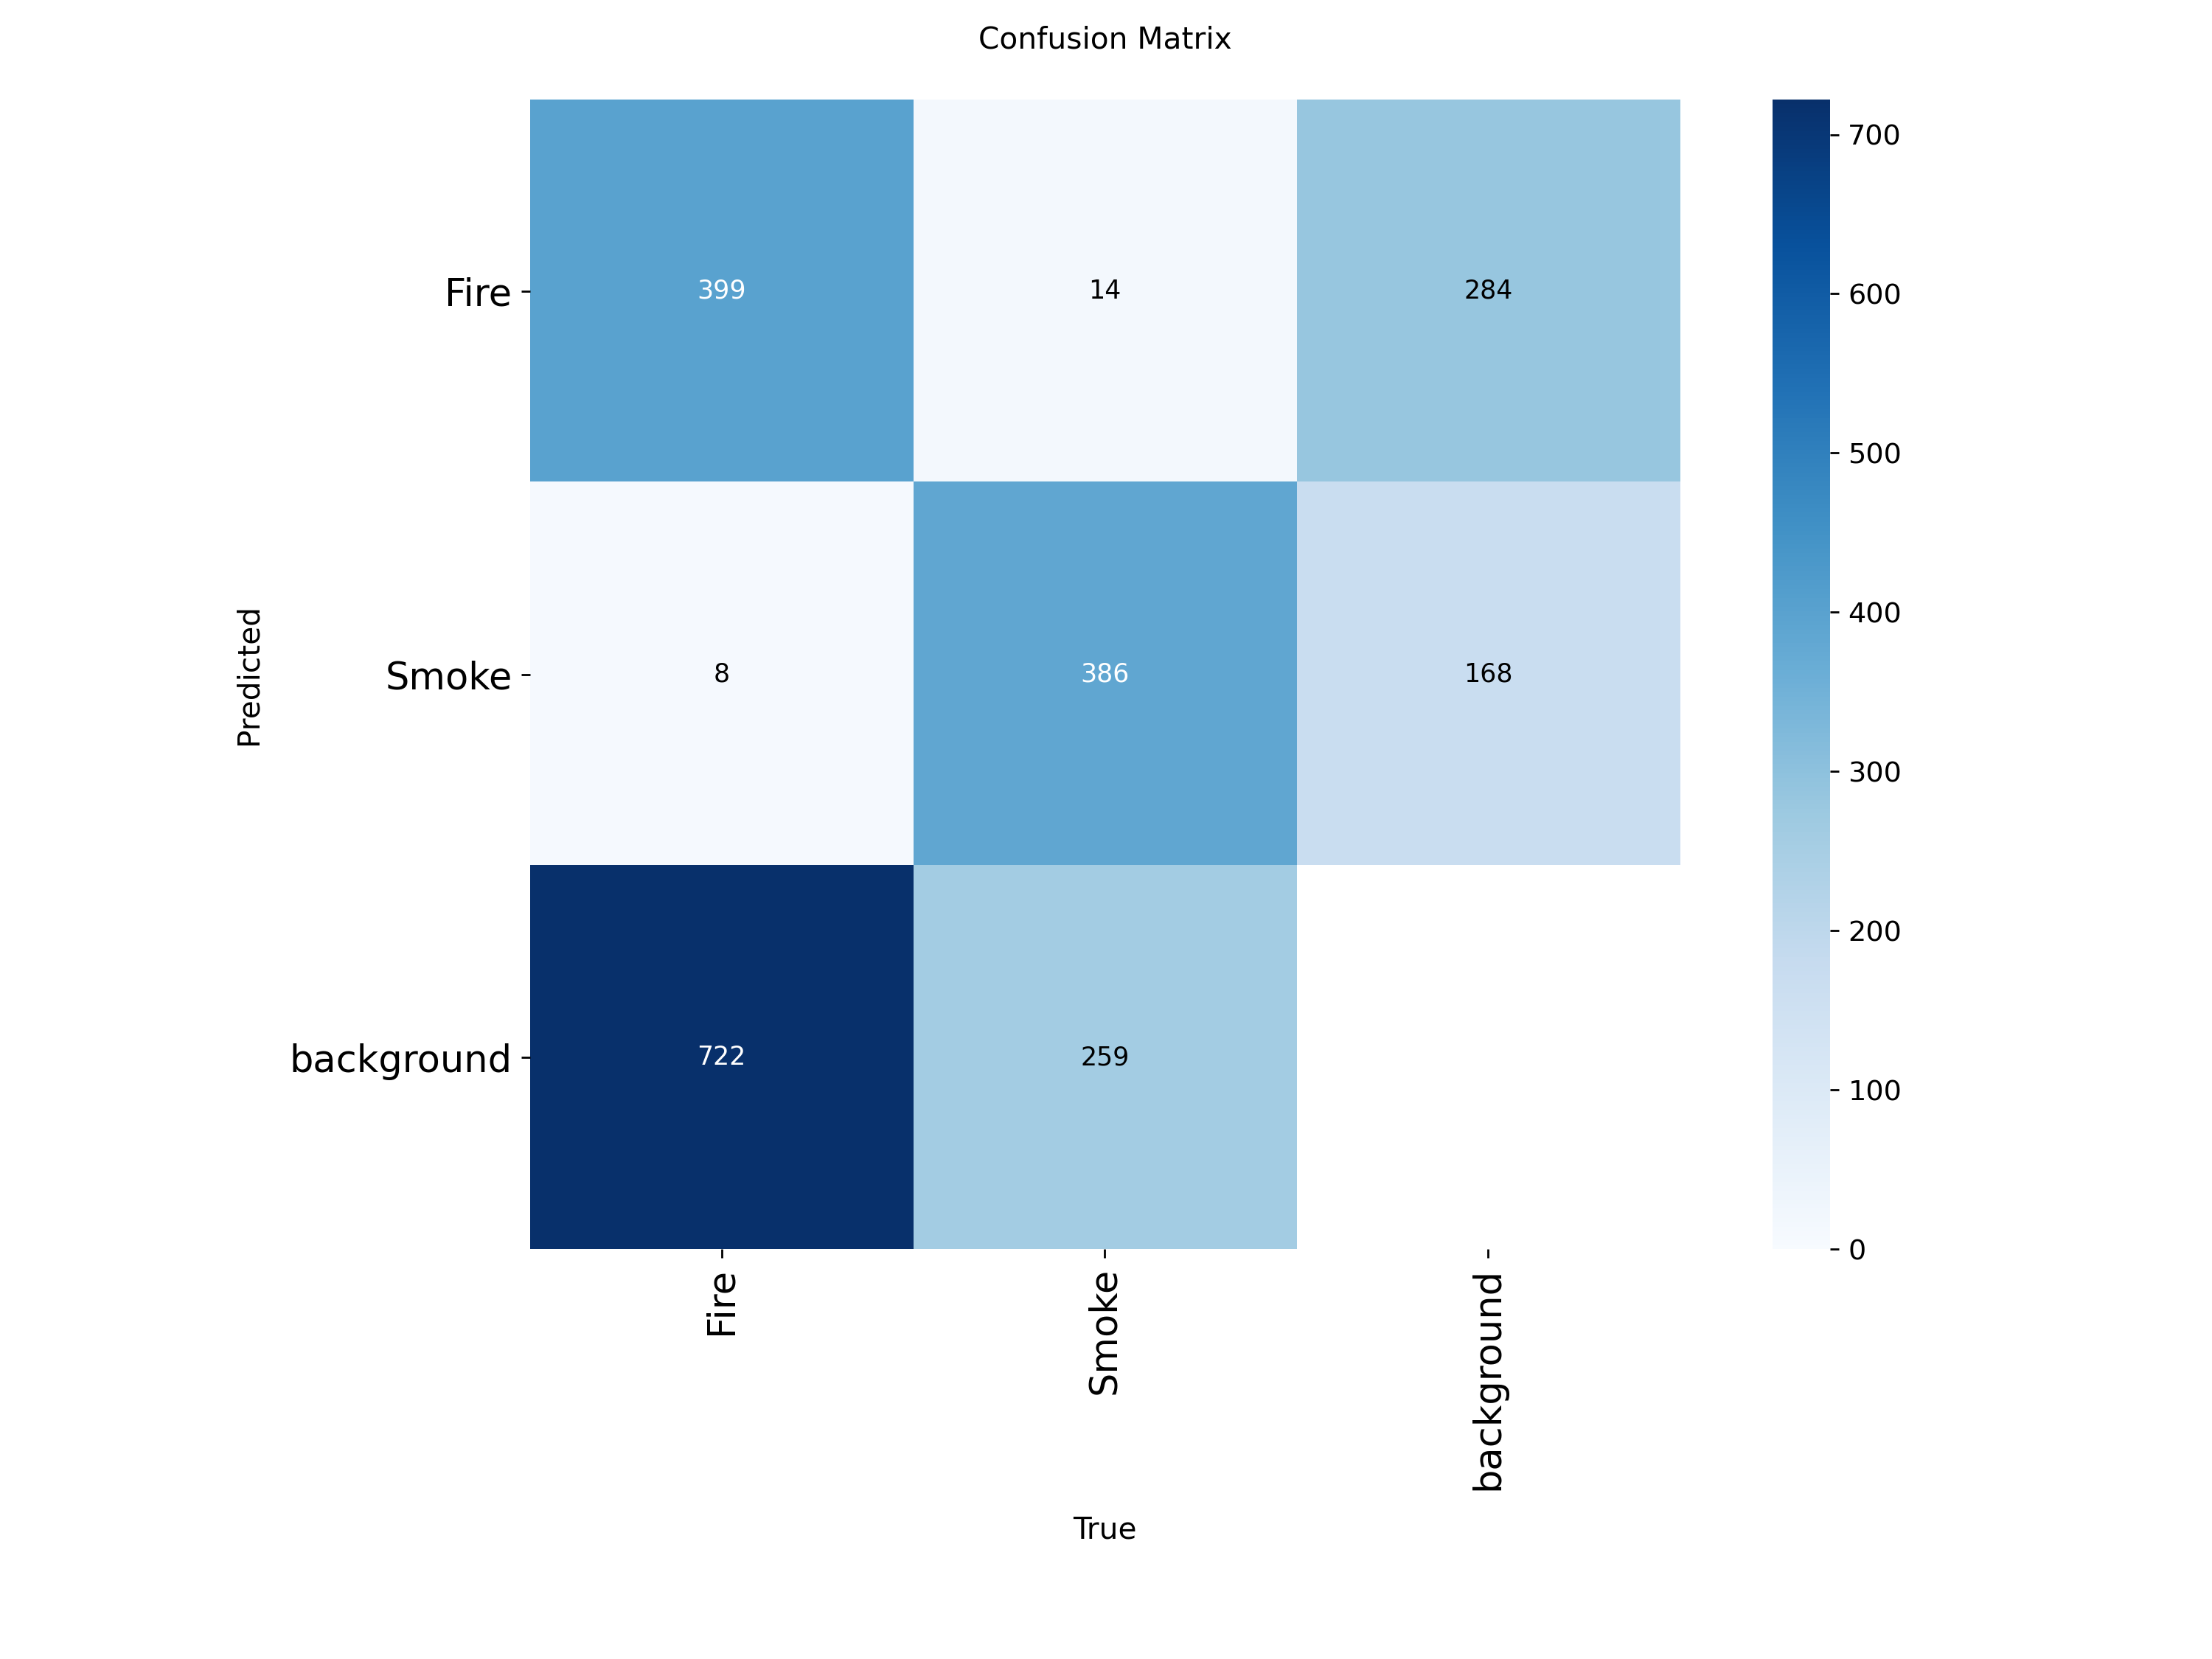

--- Validation Sample Predictions ---


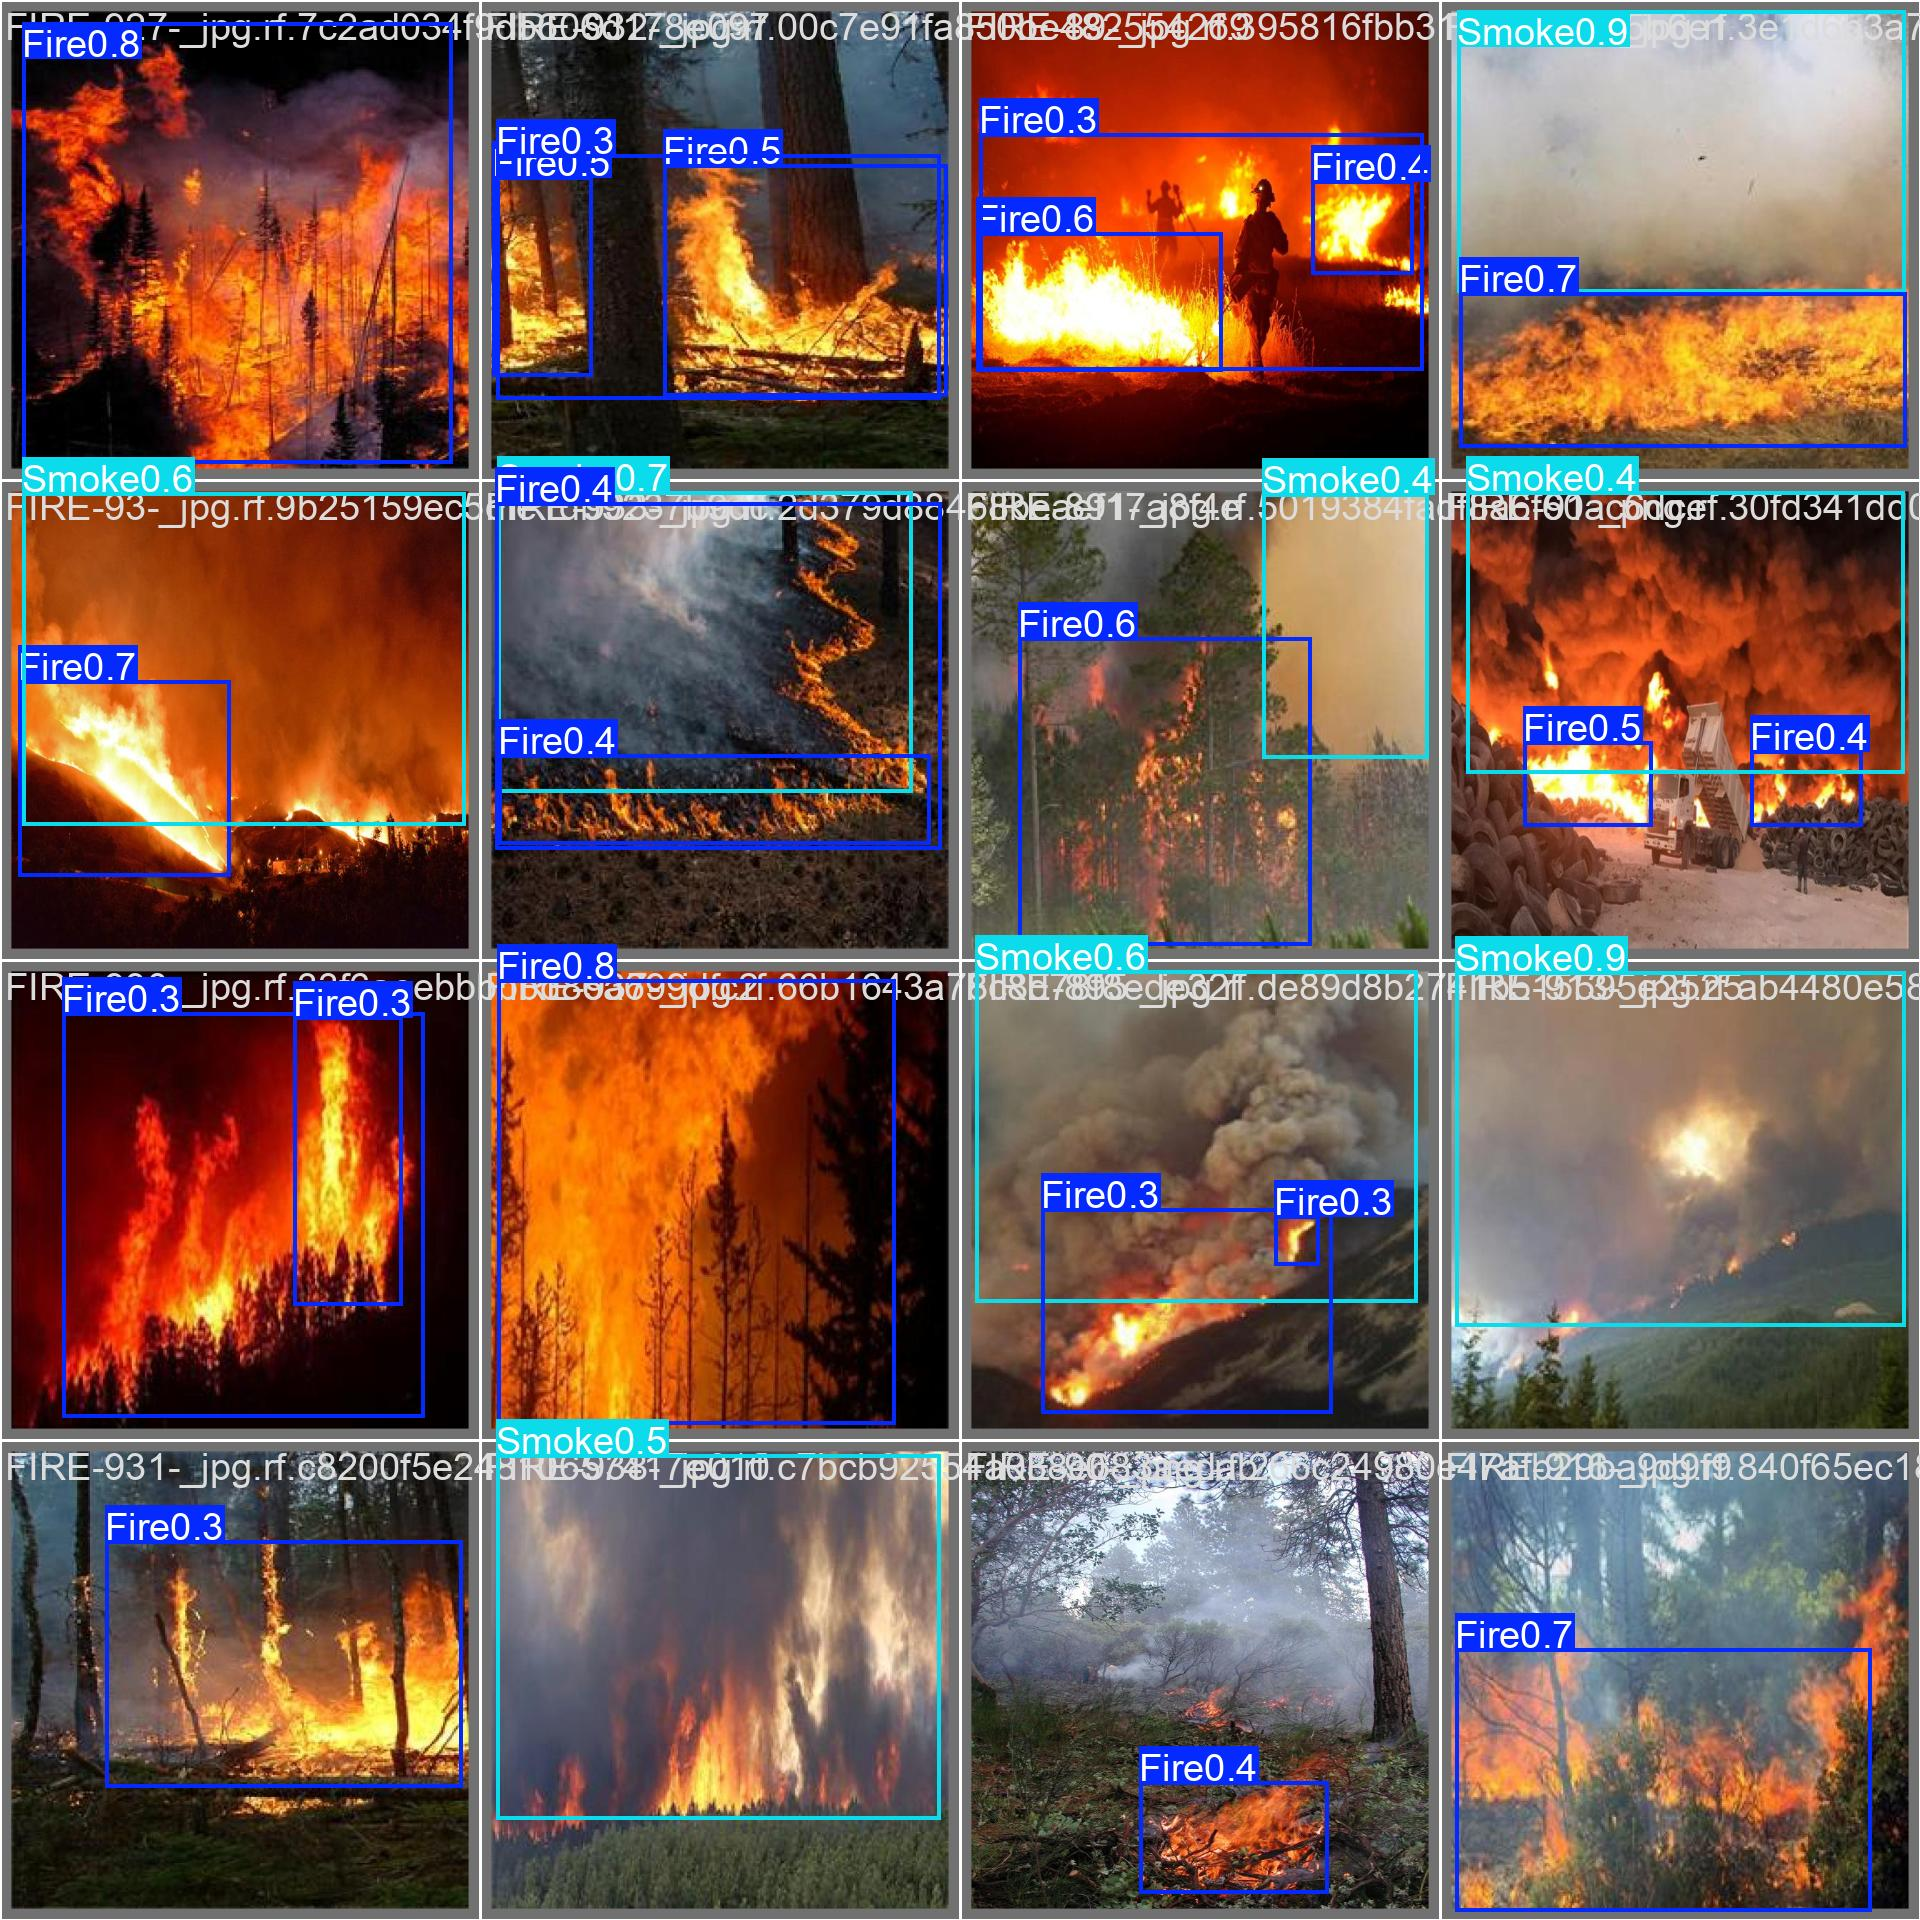

In [15]:
from IPython.display import Image, display

LATEST_RUN = "runs/detect/fire_smoke_yolov8n-3"

# 1. Overall Loss & mAP progress curves
print("--- Training Metrics (Loss & mAP Curves) ---")
display(Image(filename=f"{LATEST_RUN}/results.png"))

# 2. Confusion Matrix
print("--- Confusion Matrix ---")
display(Image(filename=f"{LATEST_RUN}/confusion_matrix.png"))

# 3. Sample Validation Ground Truth vs Model Predictions
print("--- Validation Sample Predictions ---")
display(Image(filename=f"{LATEST_RUN}/val_batch0_pred.jpg"))

In [17]:
import pandas as pd

df = pd.read_csv(f"{LATEST_RUN}/results.csv")
# Strip whitespace from headers
df.columns = df.columns.str.strip()
print("Final Epoch Performance:")
print(df.tail(1)[['epoch', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']])

Final Epoch Performance:
    epoch  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
34     35                0.5423            0.47219           0.47596   

    metrics/mAP50-95(B)  
34              0.24417  


In [18]:
import os
import shutil
from ultralytics import YOLO
from google.colab import files

LATEST_RUN = "runs/detect/fire_smoke_yolov8n-3"
EXPORT_DIR = "/content/deployment_package"
os.makedirs(EXPORT_DIR, exist_ok=True)

# 1. Export best.pt to ONNX for Raspberry Pi 5
model = YOLO(f"{LATEST_RUN}/weights/best.pt")
model.export(format="onnx", imgsz=640)

# 2. Copy only relevant model weights
shutil.copy(f"{LATEST_RUN}/weights/best.pt", f"{EXPORT_DIR}/best.pt")
shutil.copy(f"{LATEST_RUN}/weights/best.onnx", f"{EXPORT_DIR}/best.onnx")

# 3. Copy only presentation/metrics assets
metrics_files = [
    "results.png",
    "confusion_matrix.png",
    "results.csv",
    "val_batch0_pred.jpg"
]
for file_name in metrics_files:
    file_path = os.path.join(LATEST_RUN, file_name)
    if os.path.exists(file_path):
        shutil.copy(file_path, os.path.join(EXPORT_DIR, file_name))

# 4. Zip and trigger direct download
shutil.make_archive("/content/fire_smoke_essentials", "zip", EXPORT_DIR)
files.download("/content/fire_smoke_essentials.zip")

print(" Clean essentials package generated and downloading!")

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs/detect/fire_smoke_yolov8n-3/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (6.0 MB)

ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 2.1s, saved as 'runs/detect/fire_smoke_yolov8n-3/weights/best.onnx' (11.7 MB)

Export complete (2.8s)
Results saved to /content/runs/detect/fire_smoke_yolov8n-3/weights/best.onnx
Predict:         yolo predict task=detect model=runs/detect/fire_smoke_yolov8n-3/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/detect/fire_smoke_yolov8n-3/weights/best.onnx imgsz=640 data=/content/Fire-and-Smoke-6/data.yaml  
Visualize:       https://netron.app


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Clean essentials package generated and downloading!
